In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
features = pd.read_csv('market_features_weekly.csv')

In [4]:
features.head()

,Date,SP500,SP500_Return,VIX,Yield_Spread
0,1994-01-14,474.910004,0.010605,11.15,1.61
1,1994-01-21,474.720001,-0.000400,11.09,1.64
2,1994-01-28,478.700012,0.008349,9.94,1.60
3,1994-02-04,469.809998,-0.018746,15.25,1.52
4,1994-02-11,470.179993,0.000787,14.46,1.44


In [5]:
features.drop(['SP500'], axis=1, inplace=True)
print(features.head())

         Date  SP500_Return    VIX  Yield_Spread
0  1994-01-14      0.010605  11.15          1.61
1  1994-01-21     -0.000400  11.09          1.64
2  1994-01-28      0.008349   9.94          1.60
3  1994-02-04     -0.018746  15.25          1.52
4  1994-02-11      0.000787  14.46          1.44


In [6]:
features.set_index('Date', inplace=True)
print(features.head())

            SP500_Return    VIX  Yield_Spread
Date                                         
1994-01-14      0.010605  11.15          1.61
1994-01-21     -0.000400  11.09          1.64
1994-01-28      0.008349   9.94          1.60
1994-02-04     -0.018746  15.25          1.52
1994-02-11      0.000787  14.46          1.44


In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
print(features.describe())

       SP500_Return          VIX  Yield_Spread
count   1564.000000  1564.000000   1564.000000
mean       0.001482    19.663779      1.005070
std        0.024187     8.155171      0.921803
min       -0.200838     9.140000     -1.060000
25%       -0.010676    13.770000      0.240000
50%        0.002819    17.820000      0.880000
75%        0.014490    23.205000      1.770000
max        0.114237    79.129997      2.910000


In [9]:
scaler = StandardScaler()
features_std = pd.DataFrame(
    scaler.fit_transform(features),
    index=features.index,
    columns=features.columns
)
# Feature Standardization
#All modeling features are standardized using z-score normalization to ensure comparability across variables and numerical stability for unsupervised learning algorithms. Standardization is applied after weekly aggregation and feature construction.

In [10]:
print(features_std.describe().round(2))

       SP500_Return      VIX  Yield_Spread
count       1564.00  1564.00       1564.00
mean           0.00    -0.00          0.00
std            1.00     1.00          1.00
min           -8.37    -1.29         -2.24
25%           -0.50    -0.72         -0.83
50%            0.06    -0.23         -0.14
75%            0.54     0.43          0.83
max            4.66     7.29          2.07


In [11]:
features_std.to_csv("market_features_weekly_std.csv")

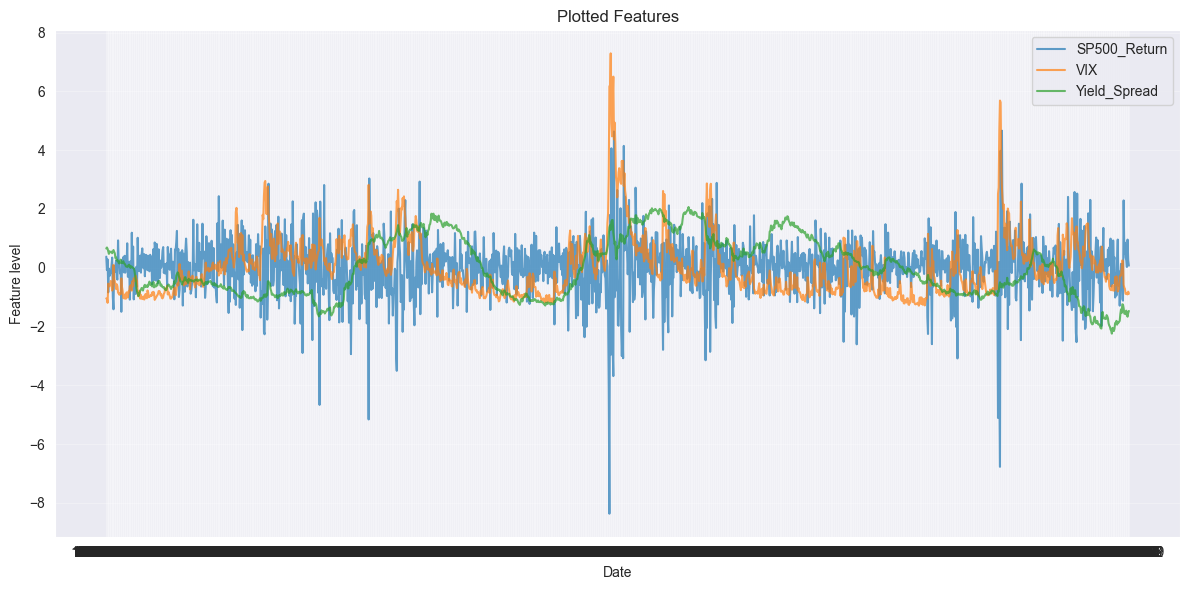

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(features_std.index, features_std["SP500_Return"], label="SP500_Return", alpha=0.7)
plt.plot(features_std.index, features_std["VIX"], label="VIX", alpha=0.7)
plt.plot(features_std.index, features_std["Yield_Spread"], label="Yield_Spread", alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Feature level")
plt.title("Plotted Standardized Features")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()